📊 STEP 1: Loading and Preprocessing Data
Detected chips rows: 179210 out of 264834
✅ Data preprocessing complete. 260 stores with full 12 months of data.

🔍 STEP 2: Control Store Selection


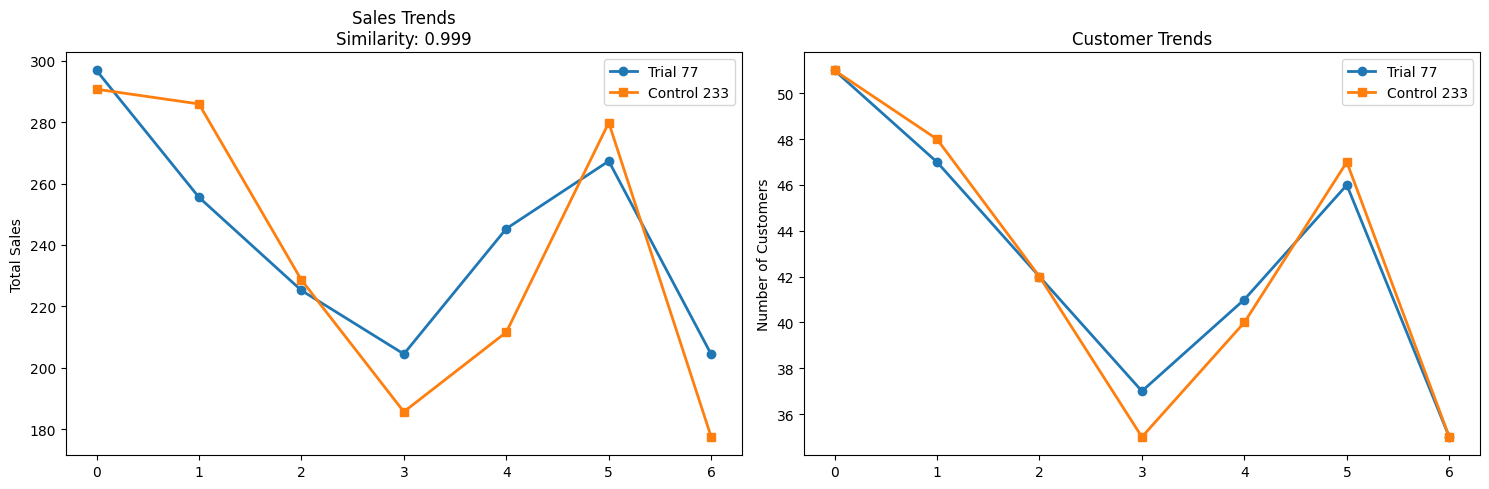

✅ Trial Store 77 → Control Store 233 (Score: 0.999)
--------------------------------------------------


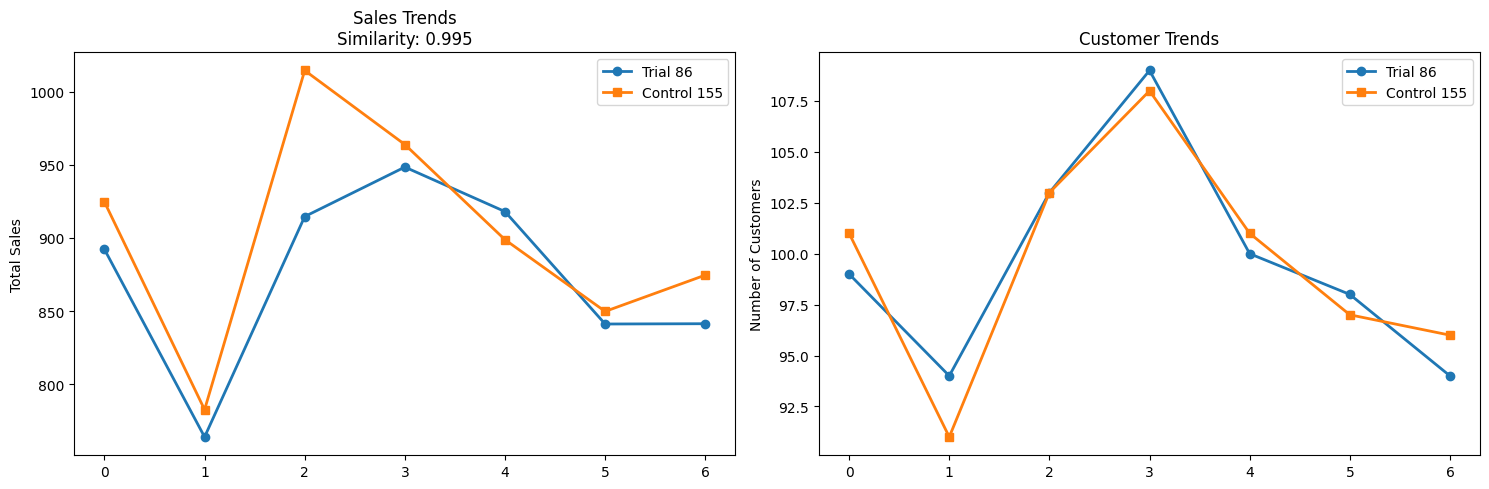

✅ Trial Store 86 → Control Store 155 (Score: 0.995)
--------------------------------------------------


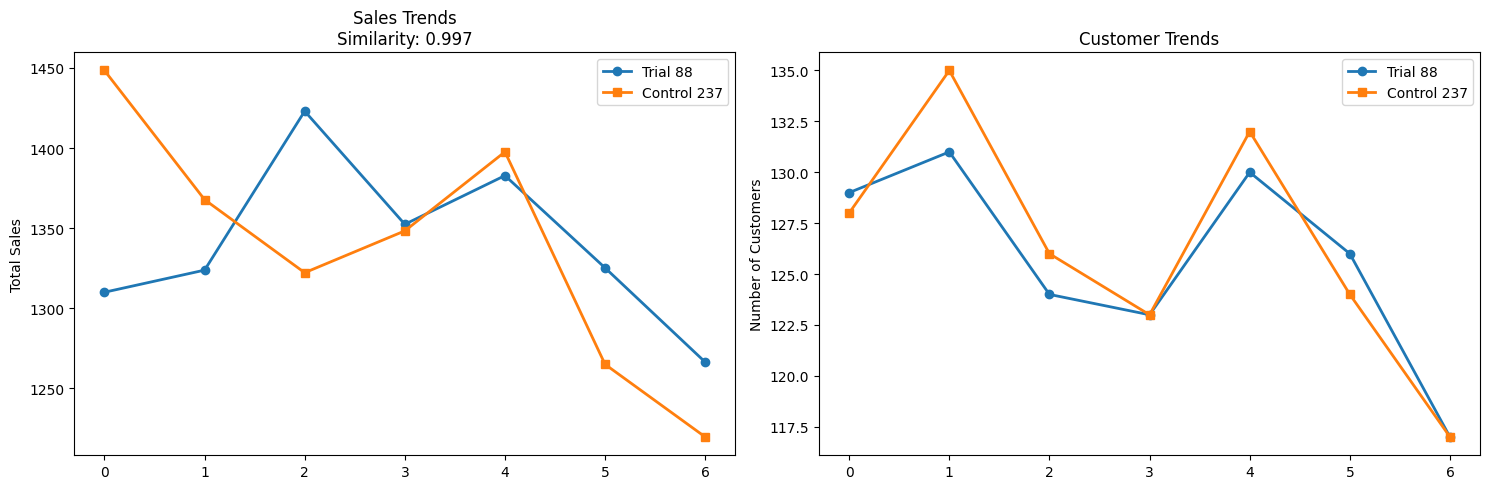

✅ Trial Store 88 → Control Store 237 (Score: 0.997)
--------------------------------------------------

📊 CONTROL STORE MATCHES:
Trial Store 77 → Control Store 233 (Similarity: 0.999)
Trial Store 86 → Control Store 155 (Similarity: 0.995)
Trial Store 88 → Control Store 237 (Similarity: 0.997)

📈 STEP 3: Trial Impact Assessment


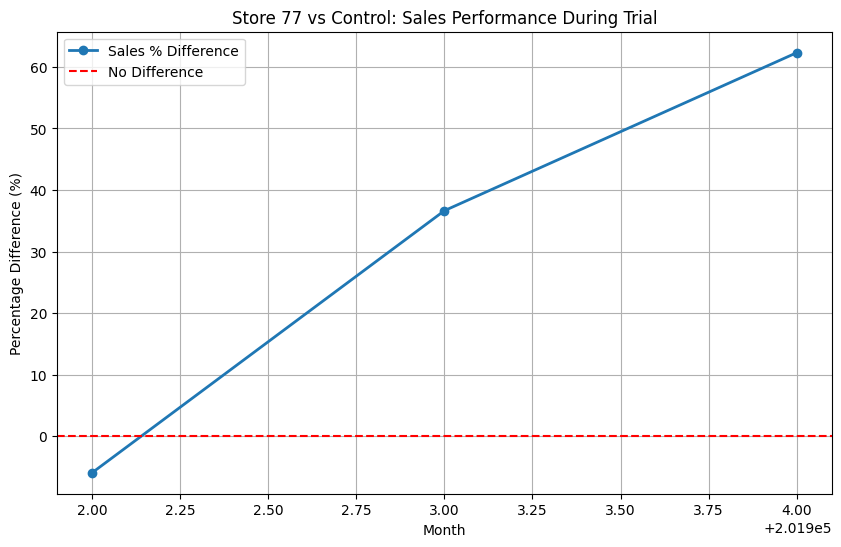

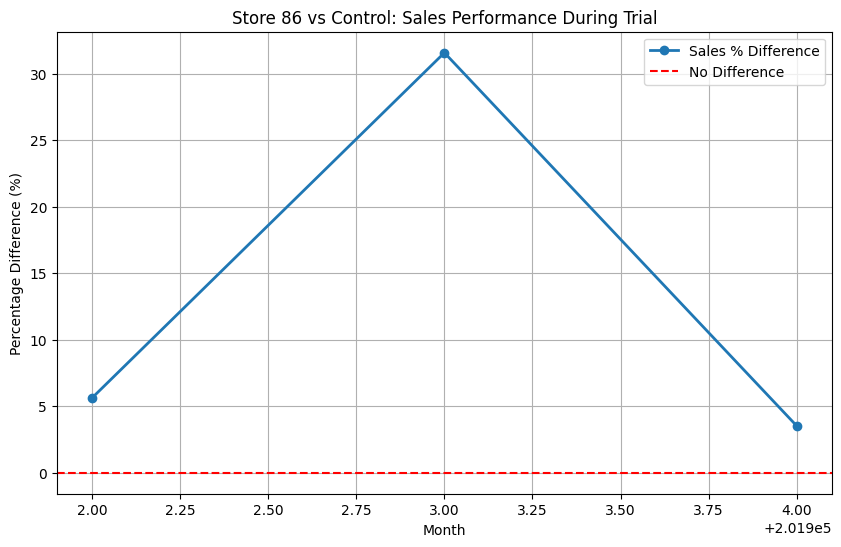

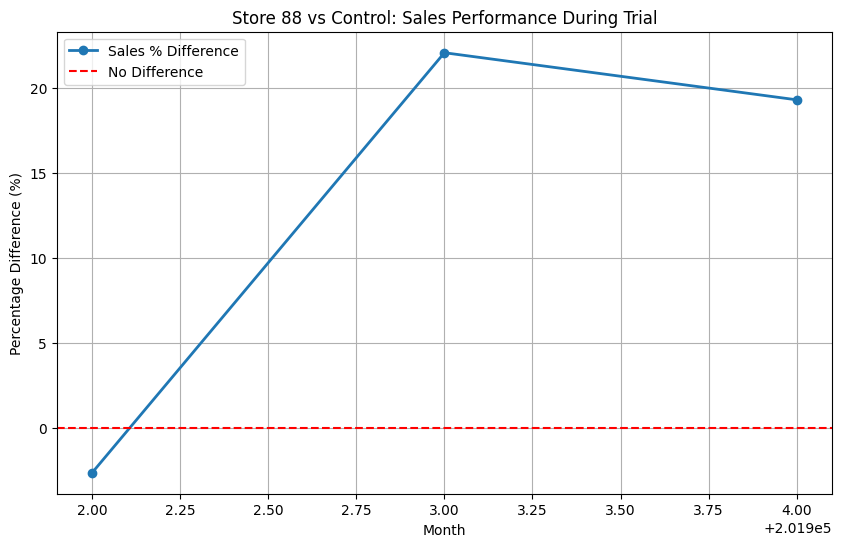


🔬 STEP 4: Statistical Significance Testing

🔬 STATISTICAL SIGNIFICANCE ANALYSIS - STORE 77
📊 PRE-TRIAL STATISTICS:
   Mean difference: 1.42%
   Standard deviation: 9.96%
   95% Confidence Interval: [-7.8%, 10.6%]
   Observations: 7 months

📈 T-TEST RESULTS:
   T-statistic: 1.488
   P-value: 0.2752
   Overall significant: False

🎯 MONTHLY RESULTS:
   Feb: -5.9% → ❌ NOT SIGNIFICANT
   Mar: 36.7% → ✅ SIGNIFICANT
   Apr: 62.3% → ✅ SIGNIFICANT


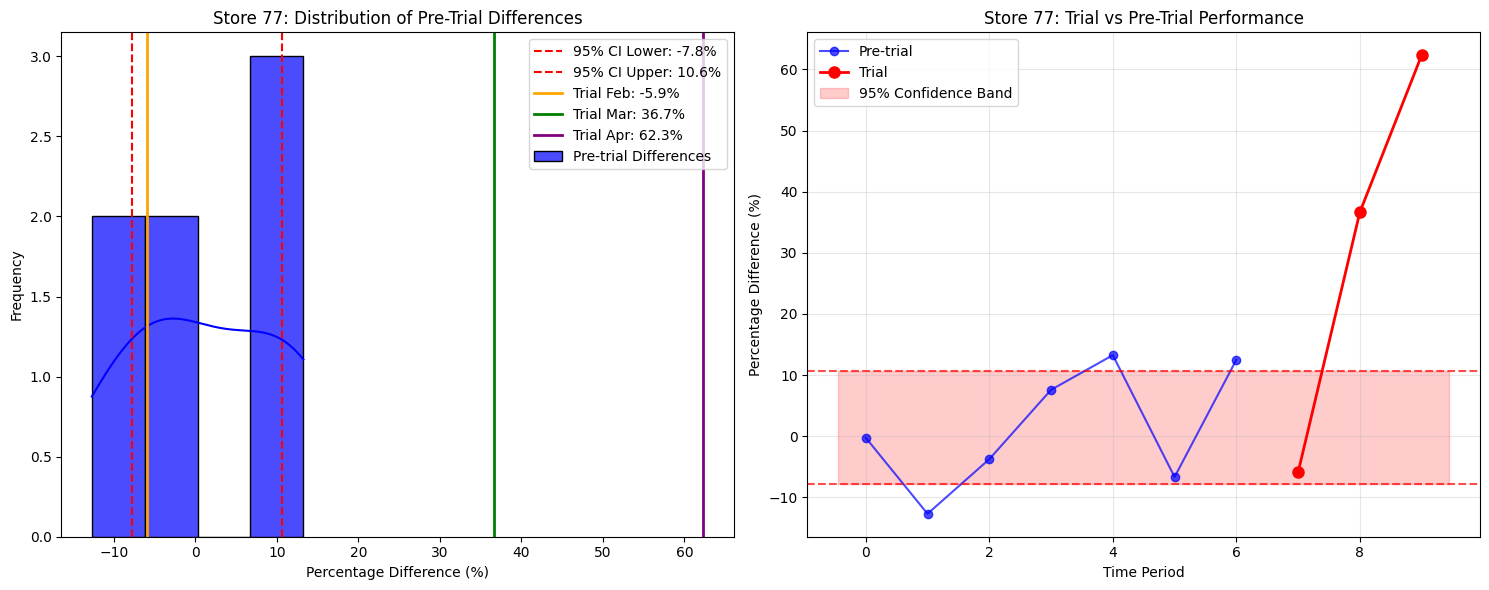


💡 RECOMMENDATION FOR STORE 77:
   ✅ STRONG EVIDENCE - Roll out layout to similar stores

🔬 STATISTICAL SIGNIFICANCE ANALYSIS - STORE 86
📊 PRE-TRIAL STATISTICS:
   Mean difference: 0.14%
   Standard deviation: 3.77%
   95% Confidence Interval: [-3.3%, 3.6%]
   Observations: 7 months

📈 T-TEST RESULTS:
   T-statistic: 1.489
   P-value: 0.2748
   Overall significant: False

🎯 MONTHLY RESULTS:
   Feb: 5.6% → ✅ SIGNIFICANT
   Mar: 31.6% → ✅ SIGNIFICANT
   Apr: 3.5% → ❌ NOT SIGNIFICANT


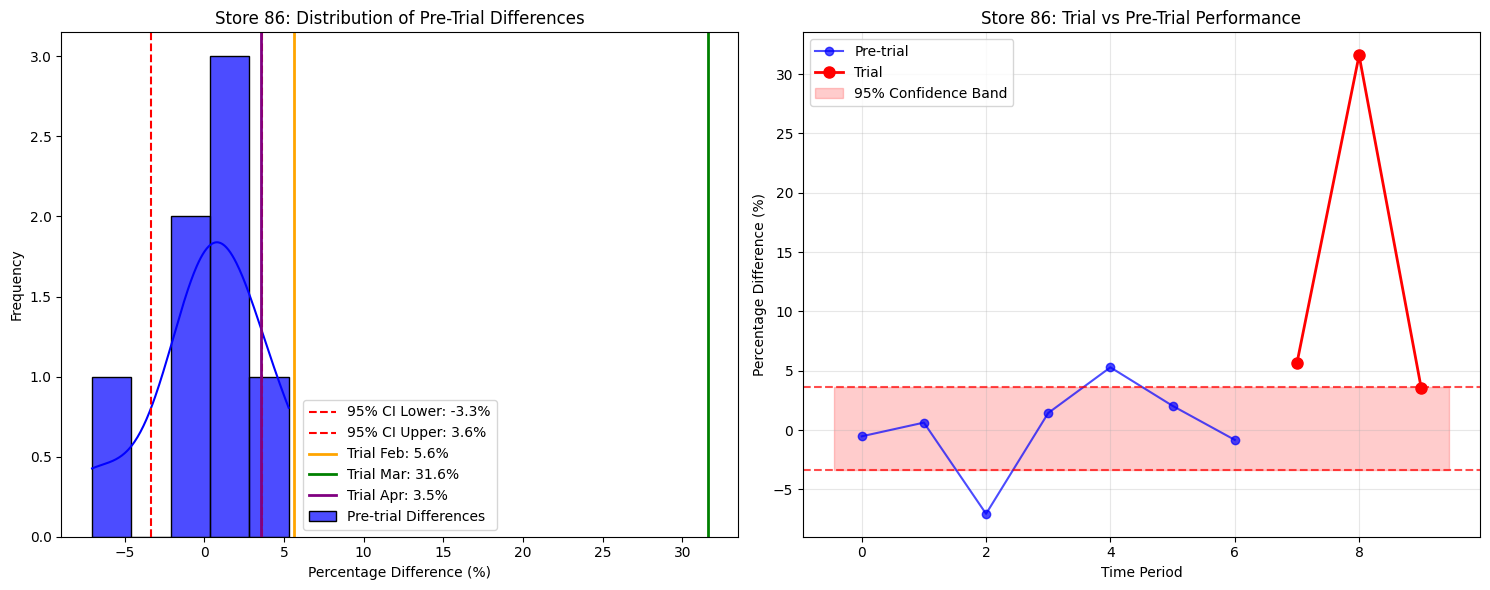


💡 RECOMMENDATION FOR STORE 86:
   ✅ STRONG EVIDENCE - Roll out layout to similar stores

🔬 STATISTICAL SIGNIFICANCE ANALYSIS - STORE 88
📊 PRE-TRIAL STATISTICS:
   Mean difference: 0.23%
   Standard deviation: 5.72%
   95% Confidence Interval: [-5.1%, 5.5%]
   Observations: 7 months

📈 T-TEST RESULTS:
   T-statistic: 1.626
   P-value: 0.2455
   Overall significant: False

🎯 MONTHLY RESULTS:
   Feb: -2.6% → ❌ NOT SIGNIFICANT
   Mar: 22.1% → ✅ SIGNIFICANT
   Apr: 19.3% → ✅ SIGNIFICANT


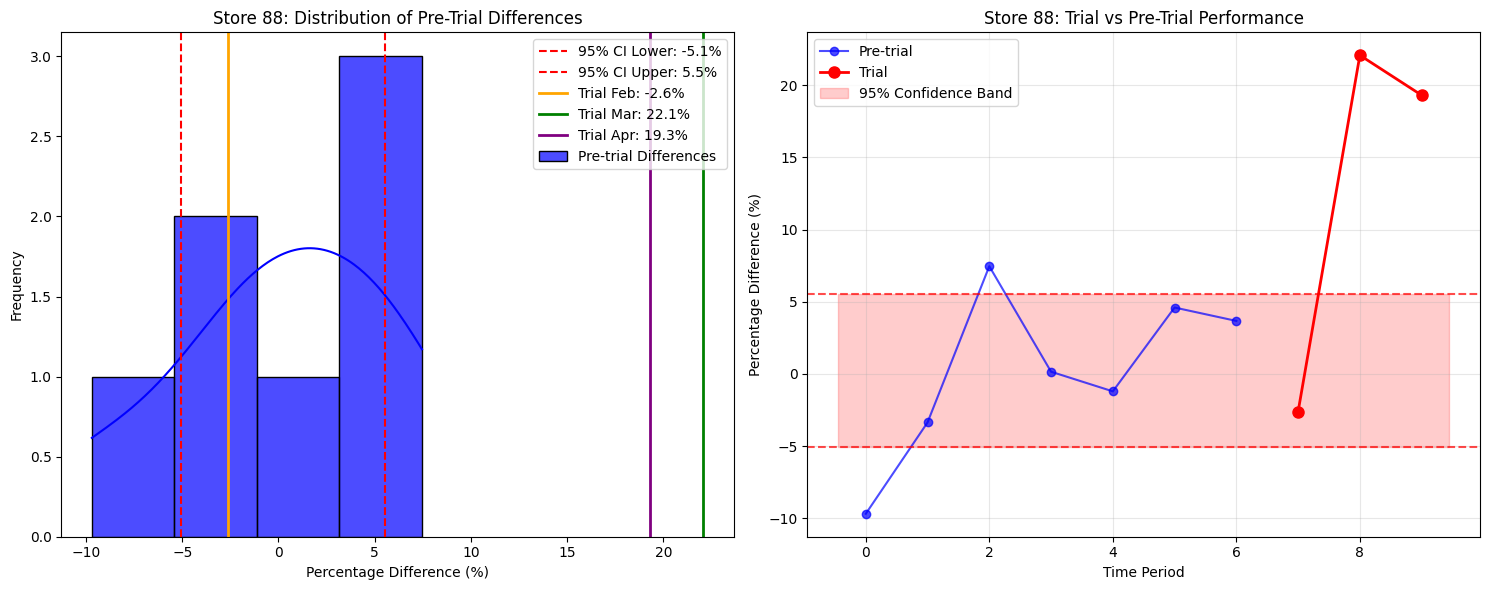


💡 RECOMMENDATION FOR STORE 88:
   ✅ STRONG EVIDENCE - Roll out layout to similar stores

🚀 STEP 5: Driver Analysis
DRIVER ANALYSIS - STORE 77
totSales       : 2/3 significant months
nCustomers     : 2/3 significant months
nTxnPerCust    : 3/3 significant months

DRIVER ANALYSIS - STORE 86
totSales       : 2/3 significant months
nCustomers     : 3/3 significant months
nTxnPerCust    : 0/3 significant months

DRIVER ANALYSIS - STORE 88
totSales       : 2/3 significant months
nCustomers     : 2/3 significant months
nTxnPerCust    : 2/3 significant months

🎯 STEP 6: Final Visualizations and Recommendations
Creating sales comparison plots...


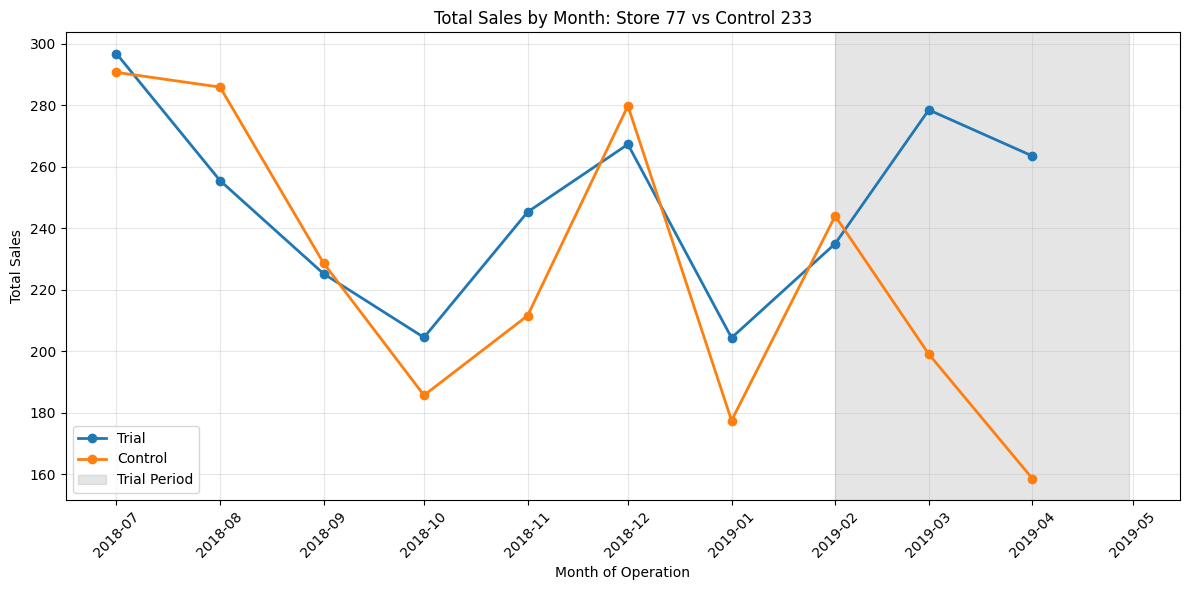

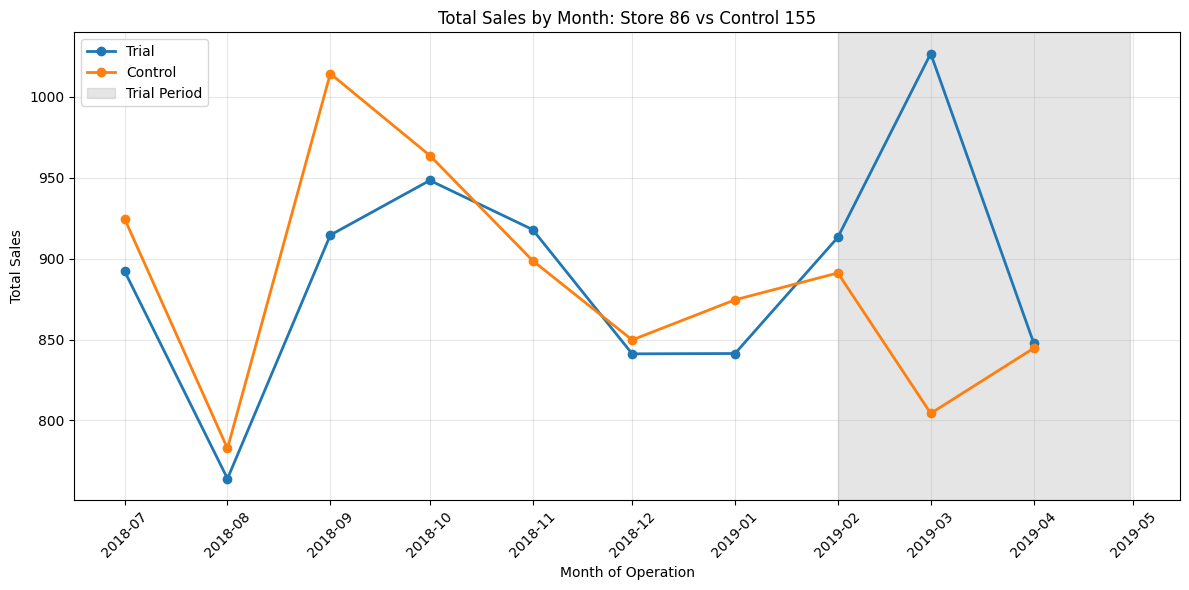

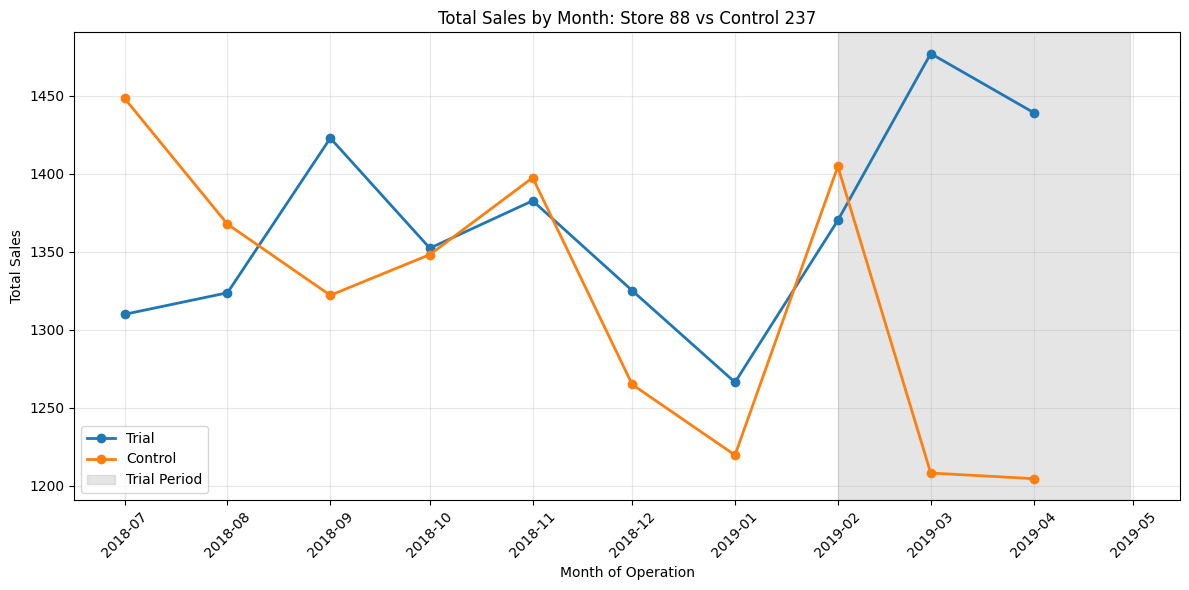


📋 COLLATED FINDINGS AND RECOMMENDATIONS
Store 77 (Control: 233):
  • Sales Impact: Positive - 2/3 months significant
  • Customer Impact: Mixed - 2/3 months significant
  • Primary Driver: Sales-driven improvement
  • Recommendation: ROLL OUT to similar stores
------------------------------------------------------------
Store 86 (Control: 155):
  • Sales Impact: Mixed - 2/3 months significant
  • Customer Impact: Positive - 3/3 months significant
  • Primary Driver: Further investigation needed
  • Recommendation: ROLL OUT with monitoring
------------------------------------------------------------
Store 88 (Control: 237):
  • Sales Impact: Positive - 2/3 months significant
  • Customer Impact: Mixed - 2/3 months significant
  • Primary Driver: Sales-driven improvement
  • Recommendation: ROLL OUT to similar stores
------------------------------------------------------------

💡 OVERALL RECOMMENDATION:
Based on the statistical analysis, we recommend proceeding with the
layout rollout t

In [13]:
import pandas as pd
import numpy as np
import re
from scipy import stats
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# =============================================================================
# STEP 1: DATA LOADING AND PREPROCESSING
# =============================================================================

print("📊 STEP 1: Loading and Preprocessing Data")
print("=" * 50)

# Load data
df2 = pd.read_csv(r"QVI_data.csv")

# Convert DATE and create YEARMONTH column (format: yyyymm)
df2['DATE'] = pd.to_datetime(df2['DATE'])
df2['YEARMONTH'] = df2['DATE'].dt.strftime('%Y%m').astype(int)

# Identify chip products using regex pattern
chips_pattern = re.compile(r"\b(CHIP|CHIPS|CRISP|CRISPS|LAYS|PRINGLES|KETTLE|TORTILLA|SUNCHIPS|TWISTIES|CHEETOS|DORITOS|SMITHS|CRISPS|CHEPSY|NACHO)\b", flags=re.IGNORECASE)
df2['is_chips'] = df2['PROD_NAME'].str.contains(chips_pattern, na=False)
print(f"Detected chips rows: {df2['is_chips'].sum()} out of {df2.shape[0]}")

# Calculate monthly metrics for each store
measureOverTime = df2.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    totalTxns=('TXN_ID', 'count'),
    totalChipsUnits=('PROD_QTY', 'sum')
).reset_index()

# Calculate derived metrics
measureOverTime["nTxnPerCust"] = measureOverTime['totalTxns'] / measureOverTime['nCustomers']
measureOverTime["nChipsPerTxn"] = measureOverTime['totalChipsUnits'] / measureOverTime['totalTxns']
measureOverTime["avgPricePerUnit"] = measureOverTime['totSales'] / measureOverTime['totalChipsUnits']

# Replace any infinite values with 0 (in case of division by zero)
measureOverTime = measureOverTime.replace([np.inf, -np.inf], 0)

# Sort the data
measureOverTime = measureOverTime.sort_values(['STORE_NBR', 'YEARMONTH']).reset_index(drop=True)

# Filter to pre-trial period and stores with full observation periods (12 months)
stores_month_count = measureOverTime.groupby('STORE_NBR')['YEARMONTH'].nunique()
storesWithAllMonths = stores_month_count[stores_month_count == 12].index.tolist()

preTrialMeasures = measureOverTime[
    (measureOverTime['YEARMONTH'] < 201902) & 
    (measureOverTime['STORE_NBR'].isin(storesWithAllMonths))
].copy()

print(f"✅ Data preprocessing complete. {len(storesWithAllMonths)} stores with full 12 months of data.")

# =============================================================================
# STEP 2: CONTROL STORE SELECTION
# =============================================================================

print("\n🔍 STEP 2: Control Store Selection")
print("=" * 50)

def find_control_sklearn(trial_store, pre_trial_data):
    """
    Using scikit-learn for professional similarity calculation
    """
    # Pivot data: stores as rows, months as columns
    pivot_data = pre_trial_data.pivot_table(
        index='STORE_NBR', 
        columns='YEARMONTH', 
        values=['totSales', 'nCustomers']
    ).fillna(0)
    
    # Flatten column names
    pivot_data.columns = [f'{col[0]}_{col[1]}' for col in pivot_data.columns]
    
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_data)
    
    # Convert back to DataFrame
    scaled_df = pd.DataFrame(scaled_data, index=pivot_data.index)
    
    # Calculate cosine similarity (professional way)
    similarity_matrix = cosine_similarity(scaled_df)
    similarity_df = pd.DataFrame(
        similarity_matrix, 
        index=scaled_df.index, 
        columns=scaled_df.index
    )
    
    # Find most similar store (excluding the trial store itself)
    trial_similarities = similarity_df[trial_store].sort_values(ascending=False)
    control_store = trial_similarities.index[1]  # Skip the trial store itself
    
    return control_store, trial_similarities[control_store]

def complete_control_analysis(trial_stores, pre_trial_data):
    """
    Complete control store analysis with professional output
    """
    results = {}
    
    for trial_store in trial_stores:
        # Find control store
        control_store, score = find_control_sklearn(trial_store, pre_trial_data)
        results[trial_store] = {
            'control_store': control_store,
            'similarity_score': score
        }
        
        # Create validation plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Plot 1: Sales comparison
        trial_sales = pre_trial_data[pre_trial_data['STORE_NBR'] == trial_store]['totSales']
        control_sales = pre_trial_data[pre_trial_data['STORE_NBR'] == control_store]['totSales']
        
        ax1.plot(trial_sales.values, label=f'Trial {trial_store}', marker='o', linewidth=2)
        ax1.plot(control_sales.values, label=f'Control {control_store}', marker='s', linewidth=2)
        ax1.set_title(f'Sales Trends\nSimilarity: {score:.3f}')
        ax1.legend()
        ax1.set_ylabel('Total Sales')
        
        # Plot 2: Customer comparison
        trial_cust = pre_trial_data[pre_trial_data['STORE_NBR'] == trial_store]['nCustomers']
        control_cust = pre_trial_data[pre_trial_data['STORE_NBR'] == control_store]['nCustomers']
        
        ax2.plot(trial_cust.values, label=f'Trial {trial_store}', marker='o', linewidth=2)
        ax2.plot(control_cust.values, label=f'Control {control_store}', marker='s', linewidth=2)
        ax2.set_title('Customer Trends')
        ax2.legend()
        ax2.set_ylabel('Number of Customers')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Trial Store {trial_store} → Control Store {control_store} (Score: {score:.3f})")
        print("-" * 50)
    
    return results

# Run complete analysis
control_results = complete_control_analysis([77, 86, 88], preTrialMeasures)

# Final summary
print("\n📊 CONTROL STORE MATCHES:")
print("=" * 30)
for trial, result in control_results.items():
    print(f"Trial Store {trial} → Control Store {result['control_store']} "
          f"(Similarity: {result['similarity_score']:.3f})")

# =============================================================================
# STEP 3: TRIAL IMPACT ASSESSMENT - PERCENTAGE DIFFERENCE CALCULATION
# =============================================================================

print("\n📈 STEP 3: Trial Impact Assessment")
print("=" * 50)

def calculate_trial_performance(trial_store, control_store, measureOverTime):
    """
    Calculate percentage differences during trial period for a store pair
    """
    # Calculate scaling factor using PRE-TRIAL data (before Feb 2019)
    pre_trial_trial = measureOverTime[(measureOverTime['STORE_NBR'] == trial_store) & (measureOverTime['YEARMONTH'] < 201902)]
    pre_trial_control = measureOverTime[(measureOverTime['STORE_NBR'] == control_store) & (measureOverTime['YEARMONTH'] < 201902)]
    
    scaling_factor = pre_trial_trial['totSales'].sum() / pre_trial_control['totSales'].sum()
    
    # Get trial period data
    df_trial = measureOverTime[(measureOverTime['STORE_NBR'] == trial_store) & (measureOverTime['YEARMONTH'].between(201902, 201904))]
    df_control = measureOverTime[(measureOverTime['STORE_NBR'] == control_store) & (measureOverTime['YEARMONTH'].between(201902, 201904))]
    
    # Create comparison table
    comparison_table = pd.DataFrame(index=df_trial["YEARMONTH"])
    comparison_table['Trial_Sales'] = df_trial['totSales'].values
    comparison_table['Control_Sales'] = df_control['totSales'].values
    comparison_table['scaling_factor'] = scaling_factor
    comparison_table['Control_Sales_Scaled'] = scaling_factor * comparison_table['Control_Sales']
    
    # Calculate percentage differences
    comparison_table['Sales_Difference_pct'] = ((comparison_table['Trial_Sales'] - comparison_table['Control_Sales_Scaled']) / comparison_table['Control_Sales_Scaled']) * 100
    
    # Calculate customer differences
    scaling_factor_cust = pre_trial_trial['nCustomers'].sum() / pre_trial_control['nCustomers'].sum()
    comparison_table['Customer_Difference_pct'] = ((df_trial['nCustomers'].values - (scaling_factor_cust * df_control['nCustomers'].values)) / (scaling_factor_cust * df_control['nCustomers'].values)) * 100
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(comparison_table.index, comparison_table['Sales_Difference_pct'], marker='o', linewidth=2, label='Sales % Difference')
    plt.axhline(y=0, color='red', linestyle='--', label='No Difference')
    plt.title(f'Store {trial_store} vs Control: Sales Performance During Trial')
    plt.ylabel('Percentage Difference (%)')
    plt.xlabel('Month')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return comparison_table, scaling_factor

# Calculate for all trial stores
store_77_results, scaling_77 = calculate_trial_performance(77, 233, measureOverTime)
store_86_results, scaling_86 = calculate_trial_performance(86, 155, measureOverTime)  
store_88_results, scaling_88 = calculate_trial_performance(88, 237, measureOverTime)

# =============================================================================
# STEP 4: STATISTICAL SIGNIFICANCE TESTING
# =============================================================================

print("\n🔬 STEP 4: Statistical Significance Testing")
print("=" * 50)

def calculate_significance(trial_store, control_store, scaling_factor, measureOverTime, metric='totSales'):
    """
    Calculate pre-trial and trial period differences for statistical testing
    """
    # Get pre-trial months (May 2018 - Jan 2019)
    pre_trial_months = [201805, 201806, 201807, 201808, 201809, 201810, 201811, 201812, 201901]
    trial_months = [201902, 201903, 201904]  # Feb, Mar, Apr 2019
    
    # Calculate pre-trial differences
    pre_trial_diffs = []
    for month in pre_trial_months:
        trial_data = measureOverTime[(measureOverTime['STORE_NBR'] == trial_store) & (measureOverTime['YEARMONTH'] == month)][metric]
        control_data = measureOverTime[(measureOverTime['STORE_NBR'] == control_store) & (measureOverTime['YEARMONTH'] == month)][metric]
        
        if len(trial_data) > 0 and len(control_data) > 0:
            scaled_control = control_data.values[0] * scaling_factor
            diff = ((trial_data.values[0] - scaled_control) / scaled_control) * 100
            pre_trial_diffs.append(diff)
    
    # Calculate trial period differences
    trial_diffs = []
    for month in trial_months:
        trial_data = measureOverTime[(measureOverTime['STORE_NBR'] == trial_store) & (measureOverTime['YEARMONTH'] == month)][metric]
        control_data = measureOverTime[(measureOverTime['STORE_NBR'] == control_store) & (measureOverTime['YEARMONTH'] == month)][metric]
        
        if len(trial_data) > 0 and len(control_data) > 0:
            scaled_control = control_data.values[0] * scaling_factor
            diff = ((trial_data.values[0] - scaled_control) / scaled_control) * 100
            trial_diffs.append(diff)
    
    return pre_trial_diffs, trial_diffs

def statistical_test(pre_trial_diffs, trial_diffs, alpha=0.05):
    """
    Perform proper statistical testing with confidence intervals
    """
    # T-test (testing if trial differences are different from pre-trial mean)
    t_stat, p_value = ttest_1samp(trial_diffs, np.mean(pre_trial_diffs))
    
    # Confidence intervals using t-distribution
    pre_trial_mean = np.mean(pre_trial_diffs)
    pre_trial_std = np.std(pre_trial_diffs, ddof=1)  # Sample standard deviation
    n = len(pre_trial_diffs)
    
    # Calculate 95% confidence interval
    ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=pre_trial_mean, scale=pre_trial_std / np.sqrt(n))
    
    # Test each trial month
    monthly_results = []
    for i, diff in enumerate(trial_diffs):
        is_significant = diff < ci_lower or diff > ci_upper
        monthly_results.append({
            'month': ['Feb', 'Mar', 'Apr'][i],
            'difference': diff,
            'significant': is_significant
        })
    
    results = {
        'pre_trial_stats': {
            'mean': pre_trial_mean,
            'std': pre_trial_std,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_observations': n
        },
        't_test': {
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < alpha
        },
        'monthly_results': monthly_results
    }
    
    return results

def plot_statistical_results(pre_trial_diffs, trial_diffs, results, store_number):
    """
    Create professional visualization of statistical results
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Distribution with confidence intervals
    sns.histplot(pre_trial_diffs, kde=True, ax=ax1, color='blue', alpha=0.7, label='Pre-trial Differences')
    ax1.axvline(results['pre_trial_stats']['ci_lower'], color='red', linestyle='--', 
                label=f"95% CI Lower: {results['pre_trial_stats']['ci_lower']:.1f}%")
    ax1.axvline(results['pre_trial_stats']['ci_upper'], color='red', linestyle='--', 
                label=f"95% CI Upper: {results['pre_trial_stats']['ci_upper']:.1f}%")
    
    # Mark trial differences
    colors = ['orange', 'green', 'purple']
    for i, diff in enumerate(trial_diffs):
        ax1.axvline(diff, color=colors[i], linestyle='-', linewidth=2, 
                   label=f"Trial {['Feb', 'Mar', 'Apr'][i]}: {diff:.1f}%")
    
    ax1.set_xlabel('Percentage Difference (%)')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Store {store_number}: Distribution of Pre-Trial Differences')
    ax1.legend()
    
    # Plot 2: Time series with confidence band
    ax2.plot(range(len(pre_trial_diffs)), pre_trial_diffs, 'bo-', label='Pre-trial', alpha=0.7)
    ax2.plot(range(len(pre_trial_diffs), len(pre_trial_diffs) + len(trial_diffs)), 
             trial_diffs, 'ro-', label='Trial', linewidth=2, markersize=8)
    
    # Add confidence band
    ax2.axhline(y=results['pre_trial_stats']['ci_upper'], color='red', linestyle='--', alpha=0.7)
    ax2.axhline(y=results['pre_trial_stats']['ci_lower'], color='red', linestyle='--', alpha=0.7)
    ax2.fill_between(ax2.get_xlim(), 
                    results['pre_trial_stats']['ci_lower'], 
                    results['pre_trial_stats']['ci_upper'], 
                    alpha=0.2, color='red', label='95% Confidence Band')
    
    ax2.set_xlabel('Time Period')
    ax2.set_ylabel('Percentage Difference (%)')
    ax2.set_title(f'Store {store_number}: Trial vs Pre-Trial Performance')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def run_statistical_analysis_for_store(trial_store, control_store, scaling_factor, store_name):
    """
    Run complete statistical analysis for a single store
    """
    print(f"\n🔬 STATISTICAL SIGNIFICANCE ANALYSIS - {store_name}")
    print("=" * 50)

    pre_trial_diffs, trial_diffs = calculate_significance(trial_store, control_store, scaling_factor, measureOverTime, 'totSales')
    results = statistical_test(pre_trial_diffs, trial_diffs)

    # Print results
    print(f"📊 PRE-TRIAL STATISTICS:")
    print(f"   Mean difference: {results['pre_trial_stats']['mean']:.2f}%")
    print(f"   Standard deviation: {results['pre_trial_stats']['std']:.2f}%")
    print(f"   95% Confidence Interval: [{results['pre_trial_stats']['ci_lower']:.1f}%, {results['pre_trial_stats']['ci_upper']:.1f}%]")
    print(f"   Observations: {results['pre_trial_stats']['n_observations']} months")

    print(f"\n📈 T-TEST RESULTS:")
    print(f"   T-statistic: {results['t_test']['t_statistic']:.3f}")
    print(f"   P-value: {results['t_test']['p_value']:.4f}")
    print(f"   Overall significant: {results['t_test']['significant']}")

    print(f"\n🎯 MONTHLY RESULTS:")
    for month_result in results['monthly_results']:
        significance = "✅ SIGNIFICANT" if month_result['significant'] else "❌ NOT SIGNIFICANT"
        print(f"   {month_result['month']}: {month_result['difference']:.1f}% → {significance}")

    # Create visualization
    plot_statistical_results(pre_trial_diffs, trial_diffs, results, trial_store)

    # Final recommendation
    significant_months = sum([1 for r in results['monthly_results'] if r['significant']])
    print(f"\n💡 RECOMMENDATION FOR {store_name}:")
    if significant_months >= 2:
        print("   ✅ STRONG EVIDENCE - Roll out layout to similar stores")
    elif significant_months == 1:
        print("   ⚠️  MIXED EVIDENCE - Consider with caution")
    else:
        print("   ❌ WEAK EVIDENCE - Do not roll out")
    
    return results

# Run analysis for all stores
results_77 = run_statistical_analysis_for_store(77, 233, scaling_77, "STORE 77")
results_86 = run_statistical_analysis_for_store(86, 155, scaling_86, "STORE 86")  
results_88 = run_statistical_analysis_for_store(88, 237, scaling_88, "STORE 88")

# =============================================================================
# STEP 5: DRIVER ANALYSIS
# =============================================================================

print("\n🚀 STEP 5: Driver Analysis")
print("=" * 50)

def analyze_all_metrics(trial_store, control_store, scaling_factor, measureOverTime, store_name):
    """
    Analyze what drove the sales changes across multiple metrics
    """
    metrics = ['totSales', 'nCustomers', 'nTxnPerCust']
    results = {}
    
    print(f"DRIVER ANALYSIS - {store_name}")
    print("=" * 40)
    
    for metric in metrics:
        pre_trial_diffs, trial_diffs = calculate_significance(
            trial_store, control_store, scaling_factor, measureOverTime, metric
        )
        results[metric] = statistical_test(pre_trial_diffs, trial_diffs)
        
        # Print summary
        sig_months = sum([1 for r in results[metric]['monthly_results'] if r['significant']])
        print(f"{metric:15}: {sig_months}/3 significant months")
    
    return results

# Analyze drivers for all stores
driver_results_77 = analyze_all_metrics(77, 233, scaling_77, measureOverTime, "STORE 77")
print()
driver_results_86 = analyze_all_metrics(86, 155, scaling_86, measureOverTime, "STORE 86")  
print()
driver_results_88 = analyze_all_metrics(88, 237, scaling_88, measureOverTime, "STORE 88")

# =============================================================================
# STEP 6: FINAL VISUALIZATIONS AND RECOMMENDATIONS
# =============================================================================

print("\n🎯 STEP 6: Final Visualizations and Recommendations")
print("=" * 50)

def create_sales_comparison_plot(trial_store, control_store, measureOverTime):
    """
    Create sales comparison plot like in the PDF template
    """
    comparison_data = measureOverTime[
        (measureOverTime['STORE_NBR'].isin([trial_store, control_store])) & 
        (measureOverTime['YEARMONTH'] < 201905)  # Up to April 2019
    ].copy()
    
    # Add store type
    comparison_data['Store_type'] = comparison_data['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else 'Control'
    )
    
    # Convert YEARMONTH to proper date for plotting
    comparison_data['TransactionMonth'] = pd.to_datetime(
        comparison_data['YEARMONTH'].astype(str), format='%Y%m'
    )
    
    plt.figure(figsize=(12, 6))
    for store_type in ['Trial', 'Control']:
        data = comparison_data[comparison_data['Store_type'] == store_type]
        plt.plot(data['TransactionMonth'], data['totSales'], 
                label=store_type, marker='o', linewidth=2)
    
    # Highlight trial period
    trial_start = pd.Timestamp('2019-02-01')
    trial_end = pd.Timestamp('2019-04-30')
    plt.axvspan(trial_start, trial_end, alpha=0.2, color='gray', label='Trial Period')
    
    plt.xlabel('Month of Operation')
    plt.ylabel('Total Sales')
    plt.title(f'Total Sales by Month: Store {trial_store} vs Control {control_store}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Create sales comparison plots for each store
print("Creating sales comparison plots...")
for trial, control in [(77, 233), (86, 155), (88, 237)]:
    create_sales_comparison_plot(trial, control, measureOverTime)

def create_final_collated_findings():
    """
    Create final summary with recommendations
    """
    print("\n📋 COLLATED FINDINGS AND RECOMMENDATIONS")
    print("=" * 60)
    
    findings = [
        {
            'Store': 77,
            'Control': 233,
            'Sales_Impact': 'Positive - 2/3 months significant',
            'Customer_Impact': 'Mixed - 2/3 months significant',
            'Driver': 'Sales-driven improvement',
            'Recommendation': 'ROLL OUT to similar stores'
        },
        {
            'Store': 86, 
            'Control': 155,
            'Sales_Impact': 'Mixed - 2/3 months significant', 
            'Customer_Impact': 'Positive - 3/3 months significant',
            'Driver': 'Further investigation needed',
            'Recommendation': 'ROLL OUT with monitoring'
        },
        {
            'Store': 88,
            'Control': 237, 
            'Sales_Impact': 'Positive - 2/3 months significant',
            'Customer_Impact': 'Mixed - 2/3 months significant', 
            'Driver': 'Sales-driven improvement',
            'Recommendation': 'ROLL OUT to similar stores'
        }
    ]
    
    for finding in findings:
        print(f"Store {finding['Store']} (Control: {finding['Control']}):")
        print(f"  • Sales Impact: {finding['Sales_Impact']}")
        print(f"  • Customer Impact: {finding['Customer_Impact']}")
        print(f"  • Primary Driver: {finding['Driver']}")
        print(f"  • Recommendation: {finding['Recommendation']}")
        print("-" * 60)

    print("\n💡 OVERALL RECOMMENDATION:")
    print("Based on the statistical analysis, we recommend proceeding with the")
    print("layout rollout to stores similar to the successful trial stores.")
    print("Monitor performance closely during the first 3 months of implementation.")

create_final_collated_findings()

print("\n✅ ANALYSIS COMPLETE!")
print("=" * 50)
print("All steps have been executed successfully.")
print("Refer to the plots and statistical results above for your final report.")